Grid scan för MESE

Ta flux från nuSIprop, se till att binna fint, smeara (inne i integralen? Utan Aeff, får se om det går hem?..), sen multiplicera med Aeff:

Aeff ~ (MESE MC events)/ (Carlos flux)

Chi2 ~ loglike(N(data från Fig.6-9) | N_(nuSI) = flux(nuSI) * Aeff)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import seaborn as sns
from scipy.stats import chi2, norm
from scipy.interpolate import interp1d
from scipy.special import factorial
from scipy.integrate import quad
import os
import sys
sys.path.append('/home/astridaurora/HESE-7-year-data-release/HESE-7-year-data-release')
from Astrid.effective_area import bin_edges_to_centers, bin_centers_to_edges, apply_energy_smearing
#import nuSIprop
#base_path = os.path.dirname(os.path.abspath(__file__))
#nuSIprop_path = os.path.abspath(os.path.join(base_path, '..', '..', 'nuSIprop-main-new'))
nuSIprop_path = '/home/astridaurora/nuSIprop-main-new'
print(nuSIprop_path)
if nuSIprop_path not in sys.path:
    sys.path.insert(0, nuSIprop_path)
import nuSIprop

#import ultranest
import h5py
import corner
import gc

import itertools
from dataclasses import dataclass
from typing import Callable, Dict, Iterable, Sequence

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from typing import Optional


energy_bins = np.logspace(4, 7, 3*20+1)
energy_centers = bin_edges_to_centers(energy_bins)
energy_bins_low_resolution = np.logspace(4, 7, 20+1)
energy_centers_low_resolution = bin_edges_to_centers(energy_bins_low_resolution)

livetime12 = 12*365*24*3600

"""hese12_events_df = pd.read_csv('4_to_7_HESE12/20bins/hese12_20bins_df.csv', index_col=0)
background_df = pd.read_csv('4_to_7_HESE12/20bins/background_20bins_df.csv', index_col=0)
background_df.rename(columns={'background': 'events'}, inplace=True)
effective_area_df = pd.read_csv('4_to_7_HESE12/60bins/effective_area_4_to_7.csv', index_col=0)"""

energy_edges_MESE = [1.0, 2.15, 4.64, 10.0, 21.5, 46.4, 100.0, 215.4, 464.2, 1000.0, 2154.4, 4641.6, 10000.0, 100000.0]
energy_centers_MESE = [1.47, 3.16, 6.81, 14.7, 31.6, 68.1, 146.8, 316.2, 681.3, 1467.8, 3162.3, 6812.9, 31622.8]

#energy_edges_MESE_BPL = [4.64, 10.0, 21.5, 46.4, 100.0, 215.4, 464.2, 1000.0, 2154.4, 4641.6, 10000.0]
#energy_centers_MESE_BPL = [6.81, 14.7, 31.6, 68.1, 146.8, 316.2, 681.3, 1467.8, 3162.3, 6812.9]

#energy_edges_MESE = [4.64, 10.0, 21.5, 46.4, 100.0, 215.4, 464.2, 1000.0, 2154.4, 4641.6, 10000.0]
#energy_centers_MESE = [6.81, 14.7, 31.6, 68.1, 146.8, 316.2, 681.3, 1467.8, 3162.3, 6812.9]
energy_edges_MESE = np.asarray(energy_edges_MESE)
energy_centers_MESE = np.asarray(energy_centers_MESE)
energy_edges_MESE *= 1e3 # GeV
energy_centers_MESE *= 1e3 # GeV

norm_segmented = [0.0, 5.4, 3.9, 4.41, 5.51, 3.34, 1.55, 0.31, 0.59, 0.327, 0.0, 0.25, 0.0]
sigma_upper = [5.2, 5.8, 2.1, 0.93, 0.72, 0.63, 0.50, 0.33, 0.42, 0.32, 0.19, 0.24, 0.76]
sigma_lower = [0.0, 5.4, 2.0, 0.90, 0.66, 0.52, 0.35, 0.31, 0.23, 0.187, 0.0, 0.16, 0.0]

# physical pivot used by the paper (100 TeV). Convert to GeV. Observed y (E^2 phi) and asymmetric errors in the same units
E0 = 1e5    # if E in GeV; 100 TeV = 1e5 GeV
y_obs = np.asarray(norm_segmented) * 1e-18 * E0**2
sigma_upper = np.asarray(sigma_upper) * 1e-18 * E0**2
sigma_lower = np.asarray(sigma_lower) * 1e-18 * E0**2
sigma1 = 2 * sigma_upper * sigma_lower / (sigma_upper + sigma_lower)    # Acts as an 'average width'
sigma2 = (sigma_upper - sigma_lower) / (sigma_upper + sigma_lower)       # Encodes the asymmetry



def SPL_flux(norm=2.13, si=2.548, energies=energy_centers_MESE):
    # SPL model flux
    # Normalized at E = 100TeV
    # Best fit MESE: norm = 2.13^{0.18}_{-0.17}, si = 2.548^{0.039}_{-0.041}
    #si, norm = theta
    norm = norm*1e-18
    return  norm * (energies / E0)**(-si)
    
    
def BPL_flux(norm=2.28, si1=1.72, si2=2.839, E_break=10**4.524, energies=energy_centers_MESE):
    # BPL model flux
    # Normalized at E = 100TeV = 1e5 GeV
    # Best fit MESE: norm = 2.28, si1 = 1.72, si2 = 2.839, E_break = 10**(4.524) GeV
    norm = norm*1e-18
    if E_break > 1e5:
        norm_break  = norm * (E_break / E0)**(-si1)
    else:
        norm_break  = norm * (E_break / E0)**(-si2)
    
    # If used for integration within the bin, energies will be a single value.
    if isinstance(energies, float):
        if energies < E_break:
            flux = norm_break * (energies / E0)**(-si1)
        else:
            flux = norm_break * (energies / E0)**(-si2)
    else:
        flux = np.zeros(len(energies))
        for i, E in enumerate(energies):
            if E < E_break:
                flux[i] = norm_break * (E / E_break)**(-si1)
            else:
                flux[i] = norm_break * (E / E_break)**(-si2)
    return flux 


def LP_flux(norm=2.58, alpha=2.669, beta=0.359, energies=energy_centers_MESE):
    # Log Parabola model flux
    # Normalized at E = 100TeV
    # Best fit MESE: norm = 2.42, alpha = 2.05, beta = 2.54
    norm = norm*1e-18
    return  norm * (energies / E0)**(-alpha - beta * np.log10(energies / E0)) 


def integrate_model_E2phi(theta, bin_edges):
    #norm, si1, si2, E_break = theta

    y_bin_avg = []
    for i in range(len(bin_edges)-1):
        Emin, Emax = bin_edges[i], bin_edges[i+1]
        Es = np.logspace(np.log10(Emin), np.log10(Emax), 50)
        if len(theta) == 2:
            norm, si = theta
            vals = SPL_flux(norm, si, energies=Es) * Es**2
        elif len(theta) == 4:
            norm, si1, si2, E_break = theta
            E_break = 10**E_break
            vals = BPL_flux(norm, si1, si2, E_break, energies=Es) * Es**2
        elif len(theta) == 3:
            norm, alpha, beta = theta
            vals = LP_flux(norm, alpha, beta, energies=Es) * Es**2

        integral = np.trapz(vals, Es)
        avg = integral / (Emax - Emin)   # <-- critical
        y_bin_avg.append(avg)
    return np.array(y_bin_avg)


def loglike(theta):
    # Valid for all flux models
    y_pred = integrate_model_E2phi(theta, energy_edges_MESE)
    y_err = (sigma1 + sigma2 * (y_pred - y_obs))
    #print('y_err: ', y_err)
    if np.any(y_err <= 0):
        print('Zeros or negatives in y_err')
        y_err[y_err <= 0] = np.abs(y_err[y_err <= 0])
        obs = y_obs[y_err <= 0]
        pred = y_pred[y_err <= 0]
        y_obs[y_err <= 0] = pred
        y_pred[y_err <= 0] = obs
        
    ll = -0.5 * np.sum((y_obs - y_pred)**2 / y_err**2) #- np.sum(np.log(y_err))
    return ll



/home/astridaurora/nuSIprop-main-new


In [15]:
@dataclass(frozen=True)
class ScanParam:
    name: Optional[str] = None
    values: Optional[Sequence[float]] = None
    label: Optional[str] = None
        
"""@dataclass(frozen=True)
class ScanParam:
    name: str
    values: Sequence[float]
    label: str | None = None"""


def run_profile_scan(
    loglike_fn: Callable[[Dict[str, float]], float],
    params: Sequence[ScanParam],
) -> tuple[Dict[str, np.ndarray], np.ndarray]:
    """
    Evaluates log-likelihood on the full Cartesian grid defined by params.

    Parameters
    ----------
    loglike_fn : callable
        Takes {param_name: value, ...} and returns log-likelihood.
    params : list[ScanParam]
        Each ScanParam supplies the grid to scan.

    Returns
    -------
    grid : dict[str, np.ndarray]
        Mapping from parameter name to numpy array of grid points.
    llh : np.ndarray
        N-D array with shape [len(p.values) for p in params].
    """
    grid = {p.name: np.asarray(p.values) for p in params}
    shape = tuple(len(p.values) for p in params)
    llh = np.empty(shape, dtype=float)

    for flat_idx, combo in enumerate(itertools.product(*grid.values())):
        idx = np.unravel_index(flat_idx, shape)
        point = dict(zip(grid.keys(), combo))
        llh[idx] = loglike_fn(point)
    return grid, llh



In [20]:
def initialize_nuSIprop(Mphi_val=5.0, g_val=1e-30, si_val=2.5, norm_val=1, mntot_val=0.1, si2_val=None, E_break_val=None, flux_model=0):
    """
    Initialize nuSIprop object with given parameters.
    
    Parameters:
    -----------
    Mphi_val : float
        Mphi parameter in GeV
    g_val : float
        g parameter
    si_val : float
        Spectral index (astro_gamma)
    mntot_val : float
        mntot parameter
    """
    original_cwd = os.getcwd()
    try:
        os.chdir(nuSIprop_path)
        evolver = nuSIprop.pyprop(
            mphi=Mphi_val * 1e6,  # Convert GeV to eV
            g=g_val,
            si=si_val,
            norm=norm_val*1e-18,
            mntot=mntot_val,
            majorana=True,
            non_resonant=True,
            normal_ordering=True,
            N_bins_E=200,  # Reduced from 300 to save memory
            lEmin=12 - 0.03,
            lEmax=17.03,
            zmax=5,  # Reduced from 4 to save memory
            flav=2,
            flux_model=flux_model,
            si2=si2_val if si2_val is not None else 2.5,
            E_break=1e9*E_break_val if E_break_val is not None else 1e9*1e5,
            phiphi=False,
        )
        evolver.evolve()
    finally:
        os.chdir(original_cwd)
    gc.collect()
    return evolver

nuSIprop_obj = initialize_nuSIprop(flux_model=1)


def model_flux_nusiprop_with_shape(E, nuSIprop_obj, flux_model, theta):
    # Function to get the diffuse flux for different models
    """
    Convenience wrapper around nuSIprop for shaped spectra (bpl/lp).
    """
    if flux_model == 0:
        norm, si = theta
        si2, E_break = None, None
        params = dict(norm=norm, si=si)
    elif flux_model == 1:
        norm, si1, si2, E_break = theta
        params = dict(norm=norm, si=si1, si2=si2, E_break=E_break)
    elif flux_model == 2:
        norm, si1, si2 = theta
        E_break = None
        params = dict(norm=norm, si=si1, si2=si2)
    
    E_eV = E * 1e9
    original_cwd = os.getcwd()
    try:
        os.chdir(nuSIprop_path)
        """params = dict(
            mphi=5 * 1e6,
            g=g if g is not None else args.g,
            si=si,
            norm=astro_norm,
            mntot=mntot if mntot is not None else args.mntot,
        )
        if si2 is not None:
            params["si2"] = si2
        if E_break is not None:
            params["E_break"] = E_break*1e9"""
        nuSIprop_obj.set_parameters(**params)
        nuSIprop_obj.evolve()
        flux_el = nuSIprop_obj.interp_flux_el(E_eV)
        flux_mu = nuSIprop_obj.interp_flux_mu(E_eV)
        flux_ta = nuSIprop_obj.interp_flux_ta(E_eV)
        flux_total = (flux_el + flux_mu + flux_ta) * 1e-18
    finally:
        os.chdir(original_cwd)
    gc.collect()
    return flux_total

    
    

def get_model_bins(theta):
    #Compute model 'event' bins using bin-integrated spectral reweighting,
    #following arXiv:2503.19960.
    
    #model_flux_function = LP_flux
    #norm, alpha, beta = theta
    #print('parameters: ', norm, alpha, beta)
    #model_flux_function = BPL_flux
    #norm, si1, si2, E_break = theta
    #E_break = 10**E_break


    N_model = np.zeros(len(energy_centers_MESE))

    for i in range(len(energy_edges_MESE) - 1):
        Emin, Emax = energy_edges_MESE[i], energy_edges_MESE[i + 1]

        # energy grid
        E = np.logspace(np.log10(Emin), np.log10(Emax), 200)
        #print(theta)
        # model flux
        #phi_model = model_flux_function(norm, alpha, beta, E)  
        #phi_model = model_flux_function(norm, si1, si2, E_break, E)
        phi_model = model_flux_nusiprop_with_shape(E=E, nuSIprop_obj=nuSIprop_obj, flux_model=1, theta=theta)
        # reference E^{-2} integral
        ref_integral = np.trapz(E**(-2), E)

        # model integral
        model_integral = np.trapz(phi_model, E)

        # model "event count"
        N_model[i] = model_integral / ref_integral
        #print(model_integral, ref_integral, N_model[i])

    return N_model

def log_likelihood_poisson(N_data, N_model):
    if N_data == 0:
        return -N_model
    else:
        return -N_model + N_data + N_data*np.log(N_model / N_data)
    
N_data = y_obs
print(N_data)
    
def loglike_new(theta):
    N_model = get_model_bins(theta)
    #print('N_model: ', N_model)
    TS = np.zeros(len(energy_centers_MESE))
    for i in range(len(energy_centers_MESE)):
        if N_model[i] > N_data[i]:
            sigma = sigma_upper[i]
        else:
            sigma =  -sigma_lower[i]
            
        if energy_centers_MESE[i] < 1e5:   # 100TeV
            TS[i] = (N_data[i] - N_model[i])**2 / (sigma**2)  # Pearson's chi2 
        else:
            if sigma <= 0:
                sigma *= (1 - 1e-4)
            #print('täljare: ', (log_likelihood_poisson(N_data[i], N_model[i]) - log_likelihood_poisson(N_data[i], N_data[i])))
            #print('nämnare: ', (log_likelihood_poisson(N_data[i], N_data[i] + sigma ) - log_likelihood_poisson(N_data[i], N_data[i])))
            TS[i] =  2*(log_likelihood_poisson(N_data[i], N_model[i]) - log_likelihood_poisson(N_data[i], N_data[i])) / (log_likelihood_poisson(N_data[i], N_data[i] + sigma ) - log_likelihood_poisson(N_data[i], N_data[i]))
    print('TS: ', np.sum(TS), ' for params: ', theta)
    return np.sum(TS)

DEBUG Cython __cinit__: STARTING
  args=(), kwargs={'mphi': 5000000.0, 'g': 1e-30, 'si': 2.5, 'norm': 1e-18, 'mntot': 0.1, 'majorana': True, 'non_resonant': True, 'normal_ordering': True, 'N_bins_E': 200, 'lEmin': 11.97, 'lEmax': 17.03, 'zmax': 5, 'flav': 2, 'flux_model': 1, 'si2': 2.5, 'E_break': 100000000000000.0, 'phiphi': False}
DEBUG Cython __cinit__: STARTING (via write)
  args=(), kwargs={'mphi': 5000000.0, 'g': 1e-30, 'si': 2.5, 'norm': 1e-18, 'mntot': 0.1, 'majorana': True, 'non_resonant': True, 'normal_ordering': True, 'N_bins_E': 200, 'lEmin': 11.97, 'lEmax': 17.03, 'zmax': 5, 'flav': 2, 'flux_model': 1, 'si2': 2.5, 'E_break': 100000000000000.0, 'phiphi': False}
DEBUG Cython __cinit__: Extracted parameters:
  mphi=5000000.0, g=1e-30, mntot=0.1, si=2.5
  norm=1e-18, majorana=True, non_resonant=True, normal_ordering=True
  N_bins_E=200, lEmin=11.97, lEmax=17.03, zmax=5
  flav=2, phiphi=False, flux_model=1, si2=2.5, E_break=100000000000000.0
DEBUG Cython: About to call C++ cons

[0.00e+00 5.40e-08 3.90e-08 4.41e-08 5.51e-08 3.34e-08 1.55e-08 3.10e-09
 5.90e-09 3.27e-09 0.00e+00 2.50e-09 0.00e+00]


In [21]:
print(len(llh_LP_new), len(grid_LP_new['norm']), len(grid_LP_new['alpha']), len(grid_LP_new['beta']))
print(grid_LP_new['norm'])

# Create meshgrids for all parameter combinations and flatten everything
norm_grid, alpha_grid, beta_grid = np.meshgrid(
    grid_LP_new['norm'], 
    grid_LP_new['alpha'], 
    grid_LP_new['beta'],
    indexing='ij'  # Use 'ij' indexing to match the order in llh_LP_new
)

# Flatten all arrays to 1D
LP_LLH_grid = pd.DataFrame({
    'LLH': llh_LP_new.flatten(),
    'norm': norm_grid.flatten(),
    'alpha': alpha_grid.flatten(),
    'beta': beta_grid.flatten()
})

LP_LLH_grid.to_csv('LP_profile_LLH_grid_MESE_carlosmethod_redshift_01.csv', index=False)
print(LP_LLH_grid)



20 20 20 20
[1.5        1.60526316 1.71052632 1.81578947 1.92105263 2.02631579
 2.13157895 2.23684211 2.34210526 2.44736842 2.55263158 2.65789474
 2.76315789 2.86842105 2.97368421 3.07894737 3.18421053 3.28947368
 3.39473684 3.5       ]
             LLH  norm  alpha      beta
0      77.394481   1.5    2.2  0.000000
1      70.493593   1.5    2.2  0.052632
2      67.280247   1.5    2.2  0.105263
3      66.467352   1.5    2.2  0.157895
4      67.115360   1.5    2.2  0.210526
...          ...   ...    ...       ...
7995  185.691974   3.5    3.2  0.789474
7996  171.414539   3.5    3.2  0.842105
7997  160.853718   3.5    3.2  0.894737
7998  153.249245   3.5    3.2  0.947368
7999  148.015702   3.5    3.2  1.000000

[8000 rows x 4 columns]


In [22]:
norm = np.linspace(1.1, 3.2, 20)
si1 = np.linspace(0.0, 3.0, 20)
si2 = np.linspace(2.4, 3.3, 20)
# Scan in log10(E_break) space for better visualization
log10_E_break = np.linspace(4, 5.0, 20)
param_names = ['norm', 'si1', 'si2', 'E_break']

def loglike_wrapper(point_dict):
    # Convert log10(E_break) back to E_break for the likelihood function
    point_dict_converted = point_dict.copy()

    theta = [point_dict_converted[name] for name in param_names]
    return loglike_new(theta)   # your existing function

grid_BPL, llh_BPL = run_profile_scan(
    loglike_wrapper,
    [
        ScanParam('norm', norm),
        ScanParam('si1', si1),
        ScanParam('si2', si2),
        ScanParam('E_break', log10_E_break),  # Use log10 space
    ],
)

TS:  67.19187249392726  for params:  [1.1, 0.0, 2.4, 4.0]
TS:  67.19187249392725  for params:  [1.1, 0.0, 2.4, 4.052631578947368]
TS:  67.19187249392726  for params:  [1.1, 0.0, 2.4, 4.105263157894737]
TS:  67.19187249392726  for params:  [1.1, 0.0, 2.4, 4.157894736842105]
TS:  67.19187249392728  for params:  [1.1, 0.0, 2.4, 4.2105263157894735]
TS:  67.19187249392725  for params:  [1.1, 0.0, 2.4, 4.2631578947368425]
TS:  67.19187249392726  for params:  [1.1, 0.0, 2.4, 4.315789473684211]
TS:  67.19187249392725  for params:  [1.1, 0.0, 2.4, 4.368421052631579]
TS:  67.19187249392725  for params:  [1.1, 0.0, 2.4, 4.421052631578947]
TS:  67.19187249392726  for params:  [1.1, 0.0, 2.4, 4.473684210526316]
TS:  67.19187249392728  for params:  [1.1, 0.0, 2.4, 4.526315789473684]
TS:  67.19187249392725  for params:  [1.1, 0.0, 2.4, 4.578947368421053]
TS:  67.19187249392728  for params:  [1.1, 0.0, 2.4, 4.631578947368421]
TS:  67.19187249392726  for params:  [1.1, 0.0, 2.4, 4.684210526315789]
TS: 

KeyboardInterrupt: 

In [ ]:
def loglike_wrapper(point_dict):

    point_dict_converted = point_dict.copy()

    theta = [point_dict_converted[name] for name in param_names]
    return loglike_new(theta)   # your existing function


norm 
"""
norm = np.linspace(1.50, 3.50, 20)
alpha = np.linspace(2.20, 3.20, 20)
beta = np.linspace(0.00, 1.00, 20)

norm = np.array([2.58, 2.34])
alpha = np.array([2.67, 2.57])
beta = np.array([0.36, 0.21])"""

param_names = ['norm', 'alpha', 'beta']

grid_LP_new, llh_LP_new = run_profile_scan(
    loglike_wrapper,
    [
        ScanParam('norm', norm),
        ScanParam('alpha', alpha),
        ScanParam('beta', beta),
    ],
)


min_LLH_lp_new = llh_LP_new.min()
lp_best_index_new = np.unravel_index(llh_LP_new.argmin(), llh_LP_new.shape)
lp_best_parameters_new = {param_names[i]: grid_LP_new[param_names[i]][lp_best_index_new[i]] for i in range(len(param_names))}
print('LP best parameters new: ', lp_best_parameters_new)
print('LLH for LP new: ', min_LLH_lp_new)

TS:  77.39448115740929  for params:  [1.5, 2.2, 0.0]
TS:  70.4935925520346  for params:  [1.5, 2.2, 0.05263157894736842]


KeyboardInterrupt: 

In [9]:
grid_LP_new = pd.read_csv('carlos_reproductions/LP_profile_LLH_grid_MESE_carlosmethod_redshift_01.csv')
#print(grid_LP_new)
llh_LP_new = np.array(grid_LP_new['LLH'].values)
print(len(llh_LP_new))
grid_LP_new = grid_LP_new.drop(columns=['LLH'])
grid_LP_new = grid_LP_new.to_dict(orient='dict')
print('parameter grid, length: ', len(grid_LP_new['norm']))
print('LLH grid, length: ', len(llh_LP_new))

8000
parameter grid, length:  8000
LLH grid, length:  8000


llh_grid shape: (20, 20, 20)
param_grid shapes: {'norm': 20, 'alpha': 20, 'beta': 20}
param_grid values:
  norm: [1.5        1.60526316 1.71052632 1.81578947 1.92105263]...[3.07894737 3.18421053 3.28947368 3.39473684 3.5       ] (length 20)
  alpha: [2.2        2.25263158 2.30526316 2.35789474 2.41052632]...[2.98947368 3.04210526 3.09473684 3.14736842 3.2       ] (length 20)
  beta: [0.         0.05263158 0.10526316 0.15789474 0.21052632]...[0.78947368 0.84210526 0.89473684 0.94736842 1.        ] (length 20)
LP best parameters new:  {'norm': 2.236842105263158, 'alpha': 2.568421052631579, 'beta': 0.2105263157894736}
LLH for LP new:  22.50452752407833
best_index:  (7, 7, 4)
3
best_parameters:  {'norm': 2.236842105263158, 'alpha': 2.568421052631579, 'beta': 0.2105263157894736}
lp_best_parameters_new:  {'norm': 2.236842105263158, 'alpha': 2.568421052631579, 'beta': 0.2105263157894736}


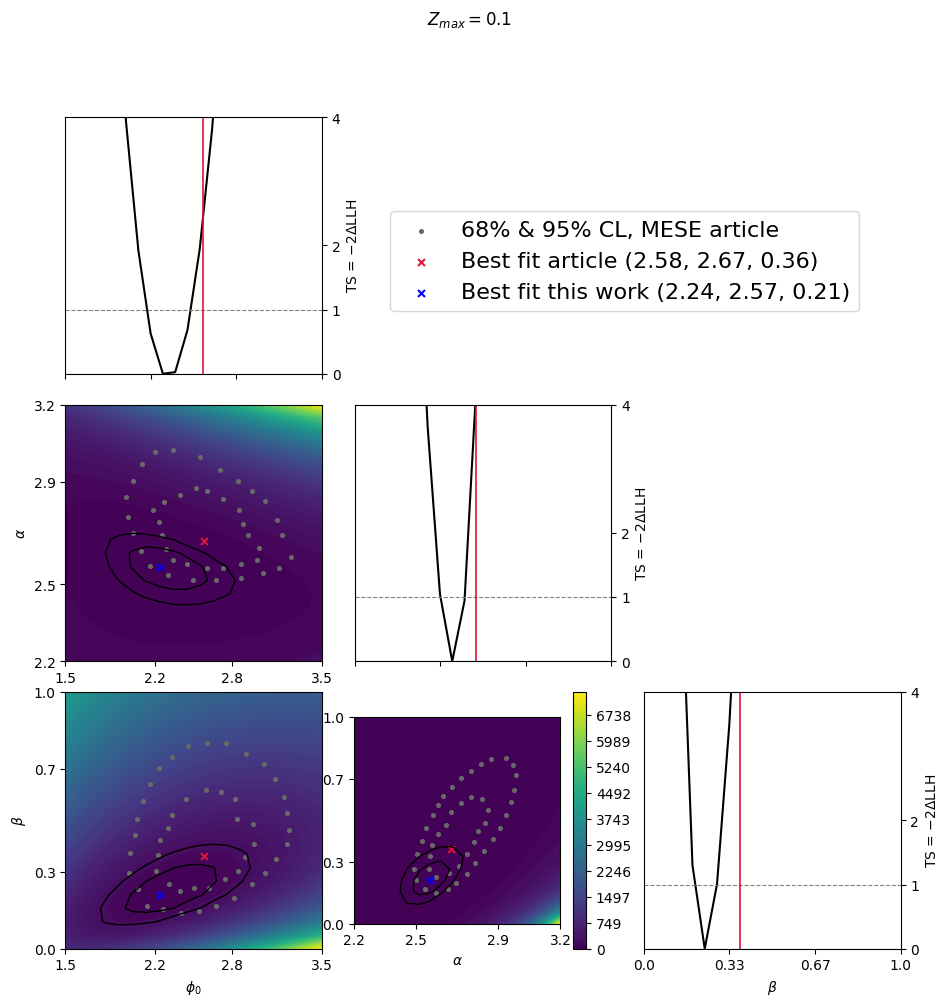

In [14]:
grid_LP_new = pd.read_csv('carlos_reproductions/LP_profile_LLH_grid_MESE_carlosmethod_redshift_01.csv')
llh_LP_new_flat = grid_LP_new['LLH'].values

# Reshape llh_LP_new from (8000,) to (20, 20, 20)
# The original grid was created with meshgrid(indexing='ij'), so shape is (norm, alpha, beta)
llh_LP_new = llh_LP_new_flat.reshape(20, 20, 20)

# Extract unique parameter values (20 values each)
# The parameters were created with np.linspace, so unique values are already sorted
grid_LP_new = grid_LP_new.drop(columns=['LLH'])
grid_LP_new = {
    'norm': np.unique(grid_LP_new['norm'].values),
    'alpha': np.unique(grid_LP_new['alpha'].values),
    'beta': np.unique(grid_LP_new['beta'].values)
}

print('llh_grid shape:', llh_LP_new.shape)
print('param_grid shapes:', {k: len(v) for k, v in grid_LP_new.items()})
print('param_grid values:')
for k, v in grid_LP_new.items():
    print(f'  {k}: {v[:5]}...{v[-5:]} (length {len(v)})')
    
min_LLH_lp_new = llh_LP_new.min()
lp_best_index_new = np.unravel_index(llh_LP_new.argmin(), llh_LP_new.shape)
lp_best_parameters_new = {param_names[i]: grid_LP_new[param_names[i]][lp_best_index_new[i]] for i in range(len(param_names))}
print('LP best parameters new: ', lp_best_parameters_new)
print('LLH for LP new: ', min_LLH_lp_new)
def plot_profile_corner(
    param_grid: Dict[str, np.ndarray],
    llh_grid: np.ndarray,
    labels: Optional[Sequence[str]] = None,
    ref_point: Optional[Dict[str, float]] = None,
    contour_levels: Iterable[float] = (2.30, 5.99),   # 68% & 95% for 2 dof
    cmap: str = 'viridis',
    panel_size: float = 3.6,                          # inches per dimension
):
    names = list(param_grid.keys())
    ndim = len(names)
    if labels is None:
        labels = names
        
    #llh_grid = llh_LP_new

    best_index = np.unravel_index(llh_grid.argmin(), llh_grid.shape)
    print('best_index: ', best_index)
    print(len(best_index))
    best_parameters = {param_names[i]: param_grid[param_names[i]][best_index[i]] for i in range(len(param_names))}
    #TS = -2.0 * (llh[best_index[0]][best_index[1]][best_index[2]][:] - llh_spl)
    print('best_parameters: ', best_parameters)

    """def profile(ts_array, keep_axes):
        axes = tuple(i for i in range(ts_array.ndim) if i not in keep_axes)
        return ts_array.max(axis=axes) if axes else ts_array"""

    fig = plt.figure(figsize=(panel_size * ndim, panel_size * ndim))
    gs = gridspec.GridSpec(ndim, ndim, wspace=0.12, hspace=0.12)

    for i, name_i in enumerate(names):
        xi = param_grid[name_i]
        ax = fig.add_subplot(gs[i, i])
        ax.set_box_aspect(1)                    # make diagonal panels square
        idx = tuple(best_index[j] if j != i else slice(None) for j in range(ndim))
        #ts_1d = -2.0 * (llh[idx] - llh_spl)
        ts_1d = (llh_grid[idx] - np.min(llh_grid))
        #ts_1d = profile(TS, (i,))
        ax.plot(xi, ts_1d, color='black')
        ax.axhline(0, color='gray', lw=0.8)
        ax.axhline(1, color='gray', lw=0.8, linestyle='--')
        #ax.axvline(outer_TS_at_4[0][i], color='crimson', linestyle='--', label='Parameter value at TS=4 in article') #Outer extent of TS at -2Delta LLH = 4 in original paper
        #ax.axvline(outer_TS_at_4[1][i], color='crimson', linestyle='--')
        yticks = np.asarray([0, 1, 2, 4])
        ylabels = [str(x) for x in yticks]
        ax.set_yticks(yticks, labels=ylabels)
        xmin, xmax = ax.get_xlim()
        xticks = np.linspace(xmin, xmax, 4)
        ax.set_xticks(xticks)
        ax.set_xticklabels([])
        if i == 2:
            ax.set_xlabel(labels[i])
            ax.set_xticklabels([0.00, 0.33, 0.67, 1.00])
        ax.set_ylabel('TS = $-2\\Delta$LLH')
        ax.set_ylim(0, 4)
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")
        if ref_point:
            ax.axvline(ref_point[name_i], color='crimson', lw=1.2)

        for j in range(i):
            name_j = names[j]
            xj = param_grid[name_j]
            ax = fig.add_subplot(gs[i, j])
            ax.set_box_aspect(1)                # square off-diagonal panels too
            #ts_2d = profile(ts_grid, (i, j))
            idx = tuple(slice(None) if k in (i, j) else best_index[k] for k in range(ndim))
            ts_2d = (llh_grid[idx] - np.min(llh_grid))
            ts_2d = ts_2d.T      # because j < i, axes come out (j,i)
            cf = ax.contourf(
                xj, xi, ts_2d,
                levels=np.linspace(ts_2d.min(), ts_2d.max(), 80),
                cmap=cmap
            )
            #ax.colorbar(cf, label='TS = $-2\\Delta$LLH')
            ax.contour(xj, xi, ts_2d,
                       levels=contour_levels,
                       colors='k', linewidths=1.0)
            """ax.contour(xj, xi, -2*(llh_LP_new[idx] - np.max(llh_LP_new)),
                       levels=contour_levels,
                       colors='g', linewidths=1.0)"""
            xmin, xmax = ax.get_xlim()
            ymin, ymax = ax.get_ylim()
            xticks = np.linspace(xmin, xmax, 4)
            yticks = np.linspace(ymin, ymax, 4)
            ax.set_xticks(np.round(xticks, 1))
            ax.set_yticks(np.round(yticks, 1))
            
            if i == 2  and j == 0:
                norm_beta = pd.read_csv('MESE_Figs10-11/norm_beta_MESE.csv', header=None)
                ax.scatter(norm_beta[0], norm_beta[1], color='dimgrey', s=7, label="68% & 95% CL, MESE article")
            if i == 2 and j == 1:
                alpha_beta = pd.read_csv('MESE_Figs10-11/alpha_beta_MESE.csv', header=None)
                ax.scatter(alpha_beta[0], alpha_beta[1], color='dimgrey', s=7, label="68% & 95% CL, MESE article")
            if i == 1 and j == 0:
                norm_alpha = pd.read_csv('MESE_Figs10-11/norm_alpha_MESE.csv', header=None)
                ax.scatter(norm_alpha[0], norm_alpha[1], color='dimgrey', s=7, label="68% & 95% CL, MESE article")

                
            if ref_point:
                if j == 1:
                    label1 = 'Best fit article (2.58, 2.67, 0.36)' 
                    print('lp_best_parameters_new: ', lp_best_parameters_new)
                    label2 = 'Best fit this work (' + str(np.round(lp_best_parameters_new['norm'], 2)) + ', ' + str(np.round(lp_best_parameters_new['alpha'], 2)) + ', ' + str(np.round(lp_best_parameters_new['beta'], 2)) + ')'
                else:
                    label1 = None
                    label2 = None
                    
                ax.scatter(ref_point[name_j], ref_point[name_i],
                           color='crimson', s=25, marker='x', label=label1)
                ax.scatter(best_parameters[name_j], best_parameters[name_i],
                           color='blue', s=25, marker='x', label=label2)
            ax.set_xlabel(labels[j])
            
            if j == 0:
                ax.set_ylabel(labels[i])
            elif j == 1:
                ax.legend(loc='upper right', bbox_to_anchor=(2.5, 3.5), fontsize=16)
                plt.colorbar(cf)
    fig.suptitle(r'$Z_{max} = 0.1$')
    return fig

param_names = ['norm', 'alpha', 'beta']
fig = plot_profile_corner(
    param_grid=grid_LP_new,
    llh_grid=llh_LP_new,
    labels=[r'$\phi_0$', r'$\alpha$', r'$\beta$'],
    ref_point={'norm': 2.58, 'alpha': 2.67, 'beta': 0.36},
    contour_levels=(2.279, 5.991))